# Single RocketPy simulation

Load a simulation-ready rocket JSON through `interpreter.py`, create a standard-atmosphere environment at the AEROPAC Black Rock Desert launch site, and run one RocketPy `Flight`.

The approximate launch-site waypoint is **40.870683° N, 119.106950° W**. AEROPAC notes that the exact pad position can change with playa conditions. The elevation is set to approximately **1,191 m above sea level**.

In [1]:
from __future__ import annotations

import json
import sys
from datetime import datetime, timedelta
from pathlib import Path
from typing import Any

from rocketpy import CompareFlights, Rocket

# Work whether Jupyter starts in the repository root or rocketpy/.
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "interpreter.py").is_file():
    PROJECT_DIR = PROJECT_DIR / "rocketpy"
if not (PROJECT_DIR / "interpreter.py").is_file():
    raise FileNotFoundError("Could not locate rocketpy/interpreter.py")

sys.path.insert(0, str(PROJECT_DIR))
from interpreter import RocketConfigurationError, load_rocket
from simrunner import run_single_simulation, runfullstacksim
from openmeteo_environment import create_openmeteo_environment

## Load a rocket JSON

Strict loading prevents a flight from starting with placeholder CDX1 values. Set `require_simulation_ready=False` only when inspecting geometry—not for a trusted simulation.

In [2]:
def load_rocket_json(
    json_path: str | Path,
    *,
    require_simulation_ready: bool = True,
) -> tuple[Rocket, dict[str, Any]]:
    """Load JSON data and construct its RocketPy Rocket."""
    path = Path(json_path)
    if not path.is_absolute():
        path = PROJECT_DIR / path
    path = path.resolve()

    with path.open(encoding="utf-8") as stream:
        configuration = json.load(stream)

    rocket = load_rocket(
        path,
        require_simulation_ready=require_simulation_ready,
    )
    return rocket, configuration

## Create the Black Rock Desert Open-Meteo environment

Call `create_openmeteo_environment` directly to fetch pressure, temperature, and wind profiles for Black Rock at the next local forecast hour.

In [3]:
BLACK_ROCK_LATITUDE = 40.870683
BLACK_ROCK_LONGITUDE = -119.106950
BLACK_ROCK_ELEVATION_M = 1191.0
BLACK_ROCK_TIMEZONE = "America/Los_Angeles"
OPENMETEO_MAX_HEIGHT_M = 80000.0

forecast_hour = datetime.now() + timedelta(hours=1)
forecast_hour = forecast_hour.replace(minute=0, second=0, microsecond=0)
forecast_date = forecast_hour.strftime("%Y-%m-%d")
forecast_time = forecast_hour.strftime("%H:%M")

openmeteo_result = create_openmeteo_environment(
    latitude=BLACK_ROCK_LATITUDE,
    longitude=BLACK_ROCK_LONGITUDE,
    date=forecast_date,
    time=forecast_time,
    timezone_name=BLACK_ROCK_TIMEZONE,
    elevation_m=BLACK_ROCK_ELEVATION_M,
    endpoint="forecast",
    max_expected_height_m=OPENMETEO_MAX_HEIGHT_M,
)

print(f"Open-Meteo profile: {forecast_date} {forecast_time} {BLACK_ROCK_TIMEZONE}")
print(f"Model top before ISA extension: {openmeteo_result.model_top_height_m:.0f} m")

Open-Meteo profile: 2026-08-21 19:00 America/Los_Angeles
Model top before ISA extension: 31609 m


## Run one flight

Use the reusable `run_single_simulation` function imported from `simrunner.py`. Launch-rail settings can be supplied through its optional keyword arguments.

## Select the rocket and simulate

Change `JSON_PATH` to any completed `rocketpy-cdx1` JSON. The supplied `test.json` still contains CDX1 placeholders, so strict loading intentionally lists the motor, inertia, drag, rail-button, and recovery data that must be added before a meaningful flight can run.


Inertia Details

Rocket Mass: 6.017 kg (without motor)
Rocket Dry Mass: 6.027 kg (with unloaded motor)
Rocket Loaded Mass: 11.793 kg
Rocket Structural Mass Ratio: 0.511
Rocket Inertia (with unloaded motor) 11: 1.729 kg*m2
Rocket Inertia (with unloaded motor) 22: 1.729 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.001 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.038099999999999995 m
Rocket Frontal Area: 0.004560 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 0.750 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.033 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.016 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
BodyTube Fins Lift Coefficient Derivative: 12.120/rad

C

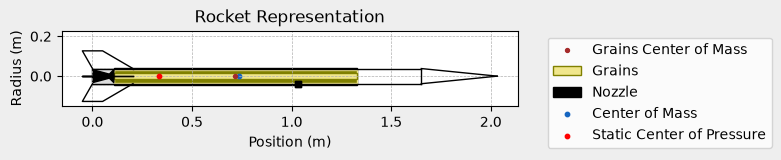


Mass Plots
----------------------------------------


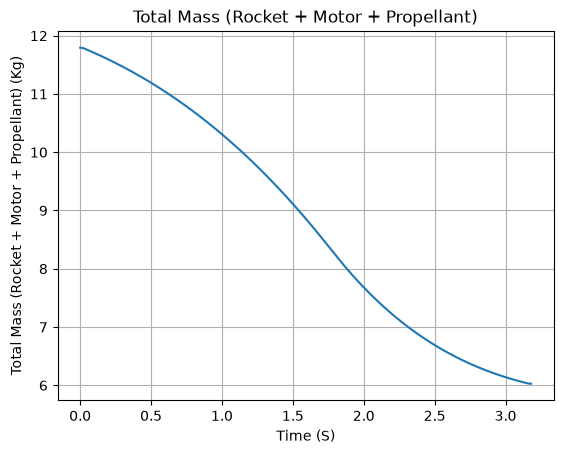

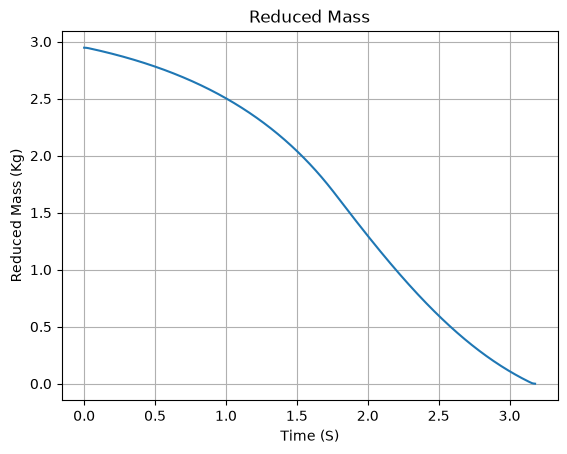


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


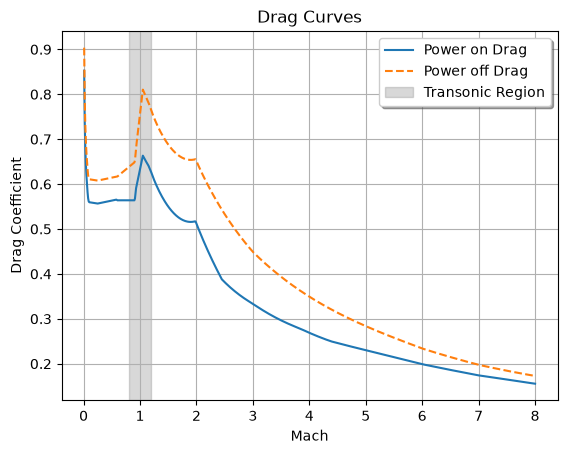


Stability Plots
--------------------


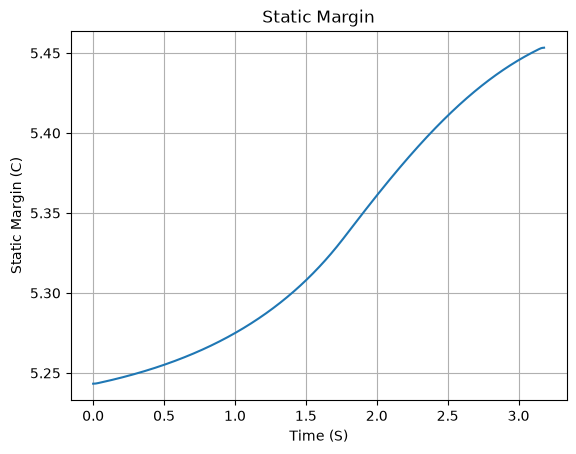

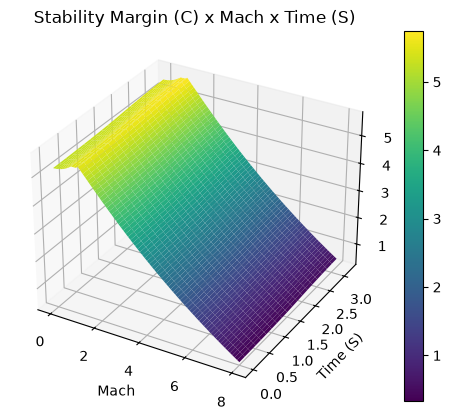


Thrust-to-Weight Plot
----------------------------------------


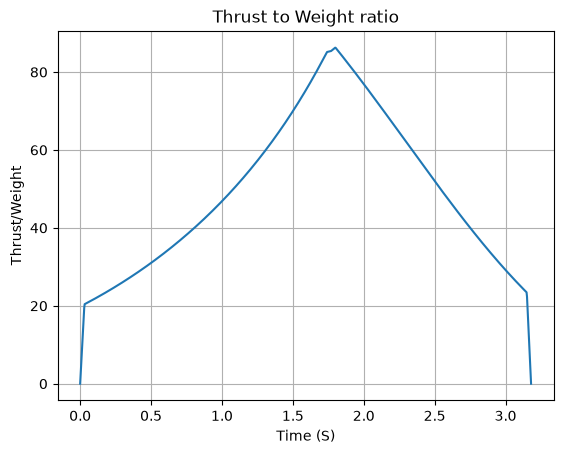

Nozzle Details
Nozzle Radius: 0.0327 m
Nozzle Throat Radius: 0.01 m

Grain Details
Number of Grains: 1
Grain Spacing: 0.0 m
Grain Density: 1799.1938061632031 kg/m3
Grain Outer Radius: 0.0327 m
Grain Inner Radius: 0.01525023420437746 m
Grain Height: 1.219202438 m
Grain Volume: 0.003 m3
Grain Mass: 5.766 kg

Motor Details
Total Burning Time: 3.18 s
Total Propellant Mass: 5.766 kg
Structural Mass Ratio: 0.002
Average Propellant Exhaust Velocity: 2292.964 m/s
Average Thrust: 4157.709 N
Maximum Thrust: 7028.1994 N at 1.74 s after ignition.
Total Impulse: 13221.514 Ns



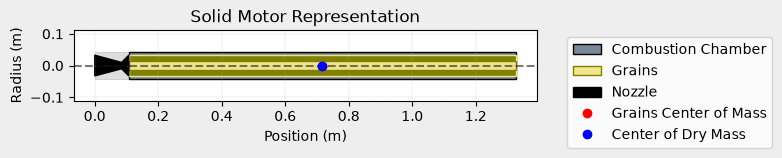

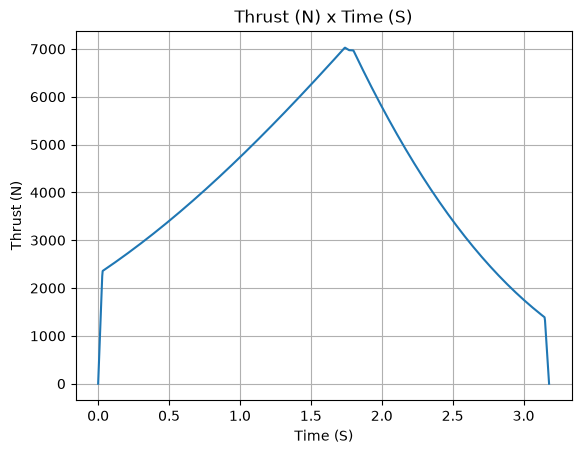

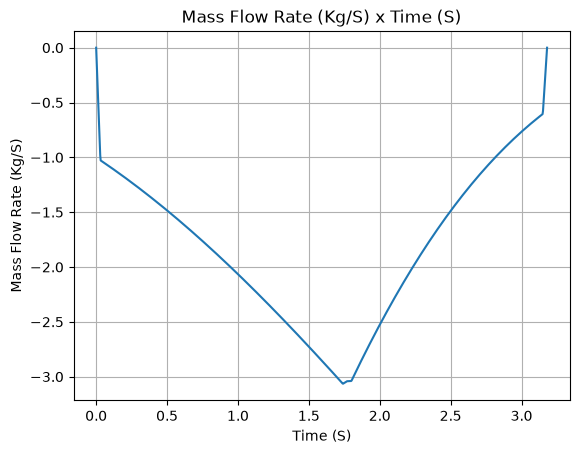

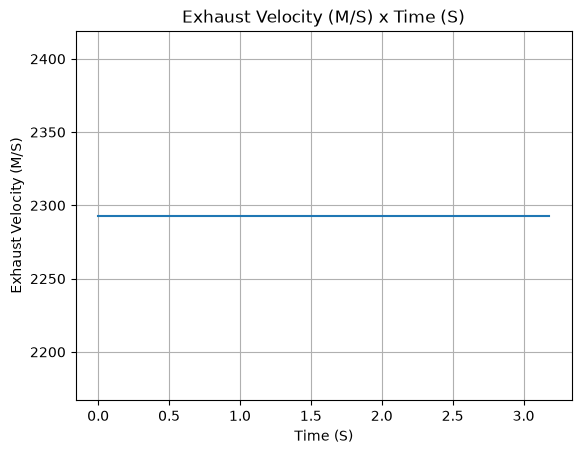

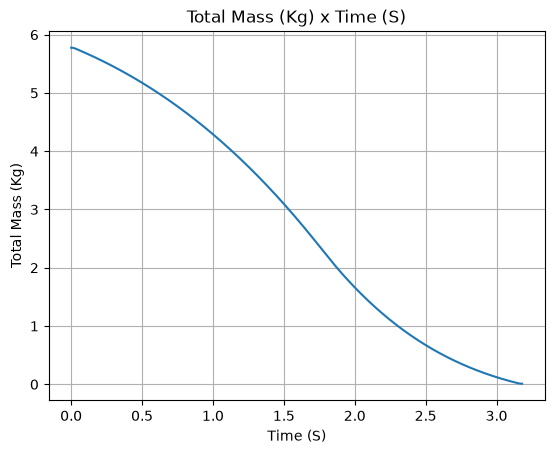

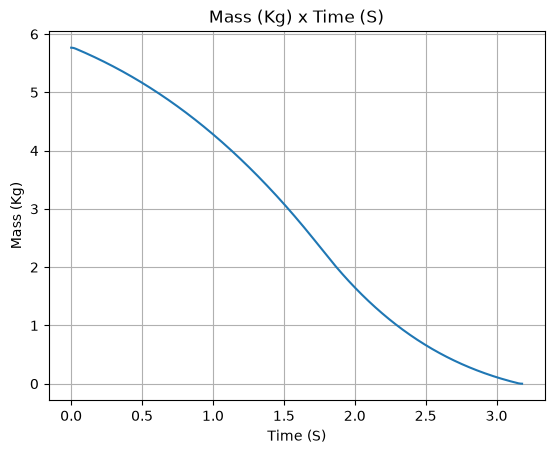

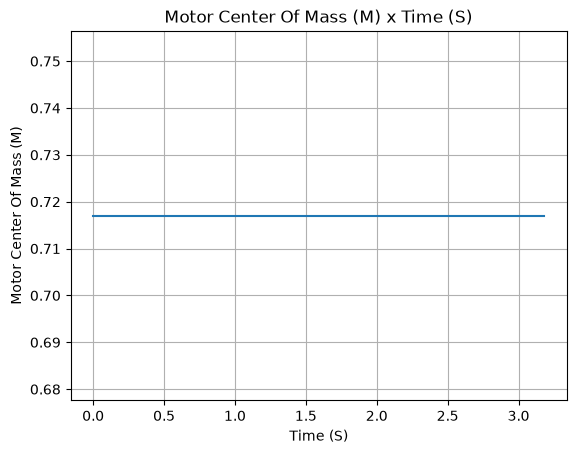

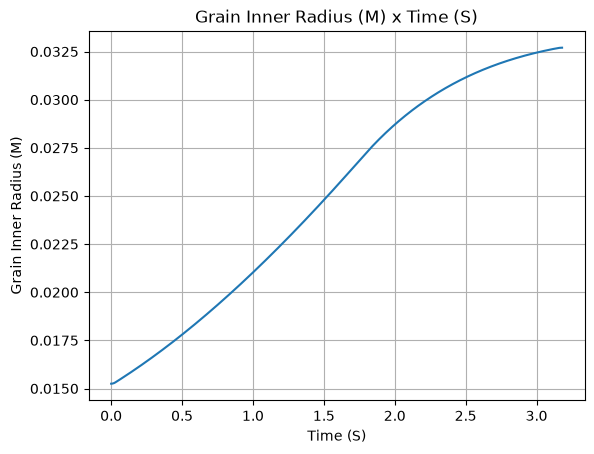

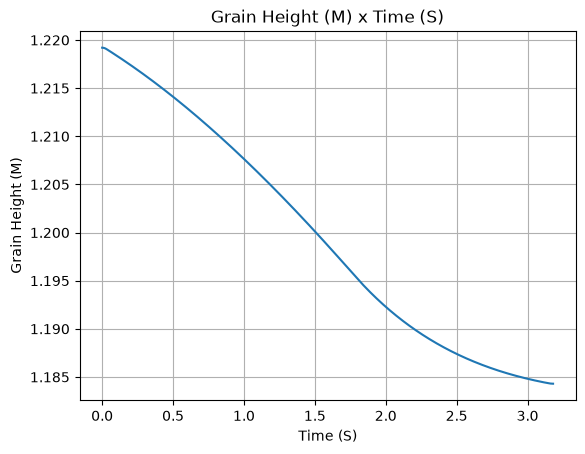

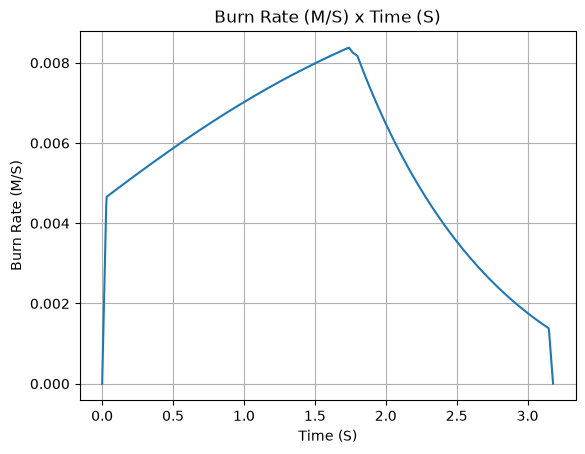

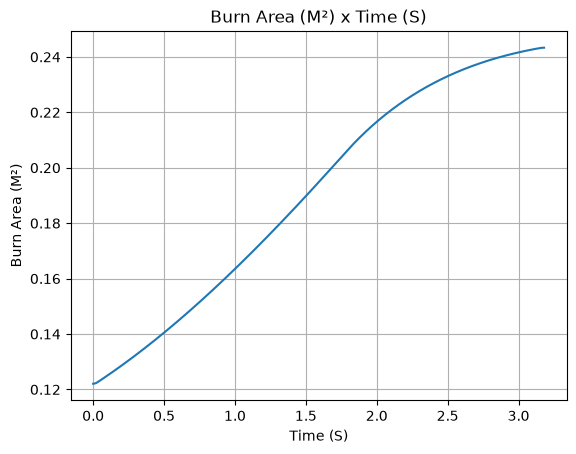

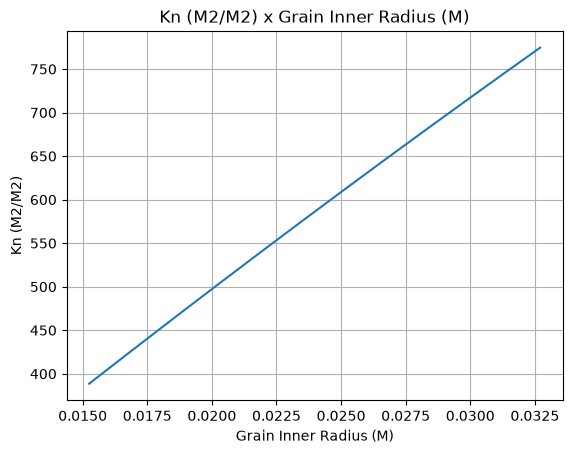

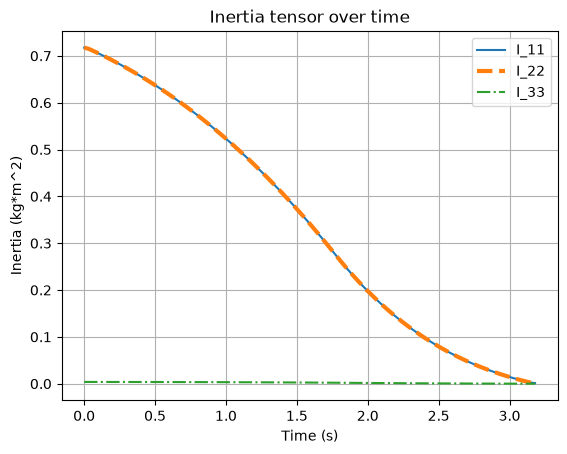

In [4]:
JSON_PATH = PROJECT_DIR / "test.json"

rocket, configuration = load_rocket_json(JSON_PATH)

rocket.all_info()

rocket.motor.all_info()
#rocket.motor.draw()

## Display all rocket information

RocketPy provides `all_info()` as the full rocket-information display call.

apogee was 57931.416797727325 ft

Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 1191.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.924 | e1: 0.000 | e2: 0.000 | e3: 0.383
Euler Angles - Spin φ : -157.50° | Nutation θ: 0.00° | Precession ψ: 202.50°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 5.243 c


Surface Wind Conditions

Frontal Surface Wind Speed: -0.30 m/s
Lateral Surface Wind Speed: 1.46 m/s


Launch Rail

Launch Rail Length: 5.2 m
Launch Rail Inclination: 90.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.219 s
Rail Departure Velocity: 42.223 m/s
Rail Departure Stability Margin: 5.253 c
Rail Departure Angle of Attack: 2.043°
Rail Departure Thrust-Weight Ratio: 24.255
Rail Departure Reynolds Number: 1.748e+05


Burn out State

Burn out time: 3.180 s
Altitude at burn out: 3279.775 m (ASL) | 2088.775 m (AGL)
Rocket speed at b

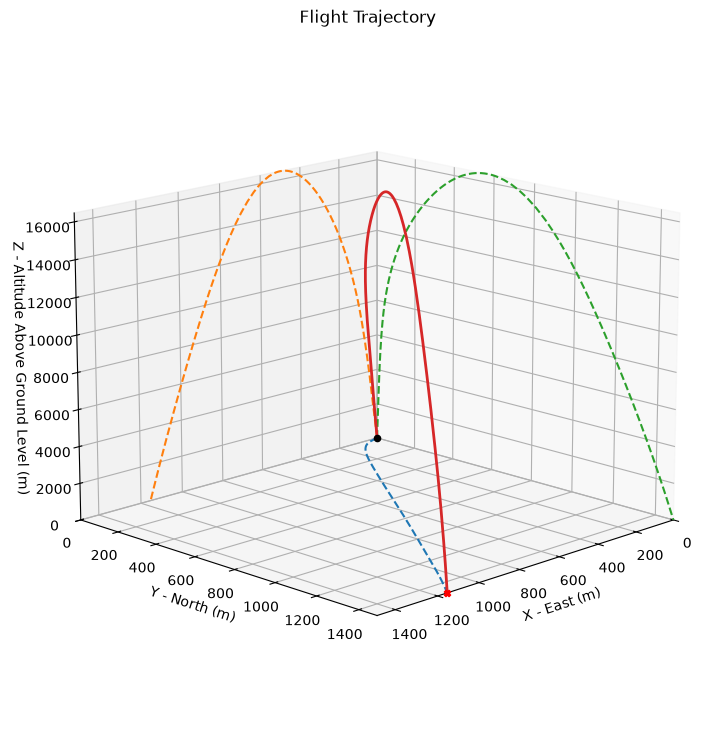

In [5]:


flight = run_single_simulation(rocket, openmeteo_result.environment)


print("apogee was " + str(flight.apogee * 3.281) + " ft")
flight.info()

flight.plots.trajectory_3d()


Inertia Details

Rocket Mass: 16.915 kg (without motor)
Rocket Dry Mass: 16.925 kg (with unloaded motor)
Rocket Loaded Mass: 28.531 kg
Rocket Structural Mass Ratio: 0.593
Rocket Inertia (with unloaded motor) 11: 18.353 kg*m2
Rocket Inertia (with unloaded motor) 22: 18.353 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.022 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0508 m
Rocket Frontal Area: 0.008107 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 1.371 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.606 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.247 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 1.125/rad
BodyTube Fins Lift Coefficient Derivative: 6.817/rad
Booster Trans

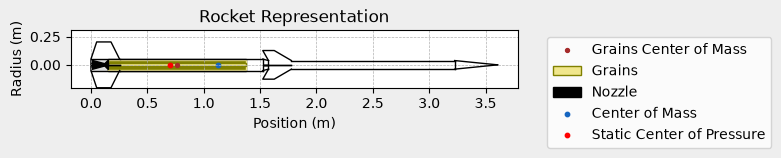

Nozzle Details
Nozzle Radius: 0.0428615 m
Nozzle Throat Radius: 0.01 m

Grain Details
Number of Grains: 1
Grain Spacing: 0.0 m
Grain Density: 1799.1938061632031 kg/m3
Grain Outer Radius: 0.0428615 m
Grain Inner Radius: 0.012369159374014704 m
Grain Height: 1.219202438 m
Grain Volume: 0.006 m3
Grain Mass: 11.606 kg

Motor Details
Total Burning Time: 4.53 s
Total Propellant Mass: 11.606 kg
Structural Mass Ratio: 0.001
Average Propellant Exhaust Velocity: 2282.352 m/s
Average Thrust: 5847.351 N
Maximum Thrust: 11351.2104 N at 3.06 s after ignition.
Total Impulse: 26488.499 Ns



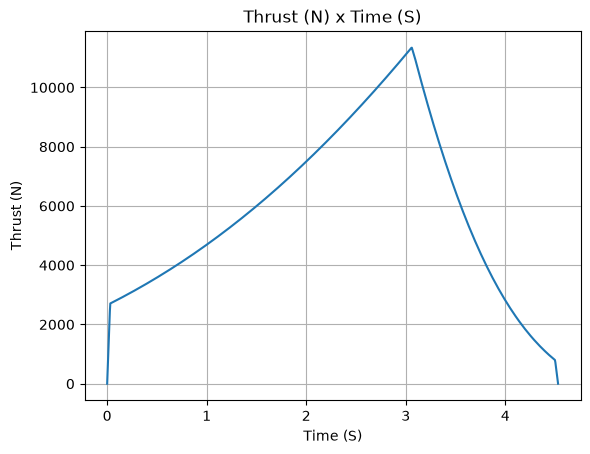

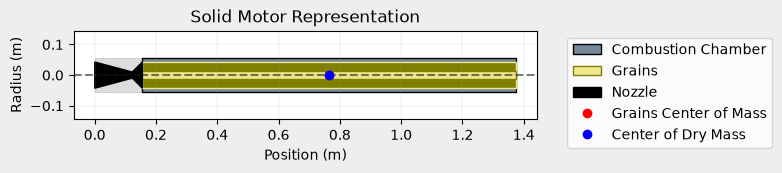


Inertia Details

Rocket Mass: 6.017 kg (without motor)
Rocket Dry Mass: 6.027 kg (with unloaded motor)
Rocket Loaded Mass: 11.793 kg
Rocket Structural Mass Ratio: 0.511
Rocket Inertia (with unloaded motor) 11: 2.074 kg*m2
Rocket Inertia (with unloaded motor) 22: 2.074 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.004 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.038099999999999995 m
Rocket Frontal Area: 0.004560 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 0.750 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.033 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.016 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
BodyTube Fins Lift Coefficient Derivative: 12.120/rad

C

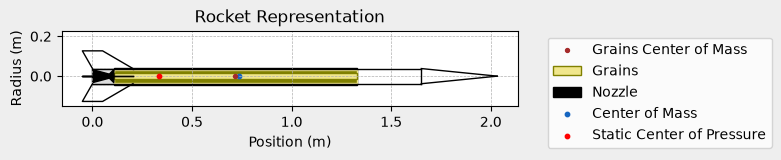

Nozzle Details
Nozzle Radius: 0.0327 m
Nozzle Throat Radius: 0.01 m

Grain Details
Number of Grains: 1
Grain Spacing: 0.0 m
Grain Density: 1799.1938061632031 kg/m3
Grain Outer Radius: 0.0327 m
Grain Inner Radius: 0.01525023420437746 m
Grain Height: 1.219202438 m
Grain Volume: 0.003 m3
Grain Mass: 5.766 kg

Motor Details
Total Burning Time: 3.18 s
Total Propellant Mass: 5.766 kg
Structural Mass Ratio: 0.002
Average Propellant Exhaust Velocity: 2292.964 m/s
Average Thrust: 4157.709 N
Maximum Thrust: 7028.1994 N at 1.74 s after ignition.
Total Impulse: 13221.514 Ns



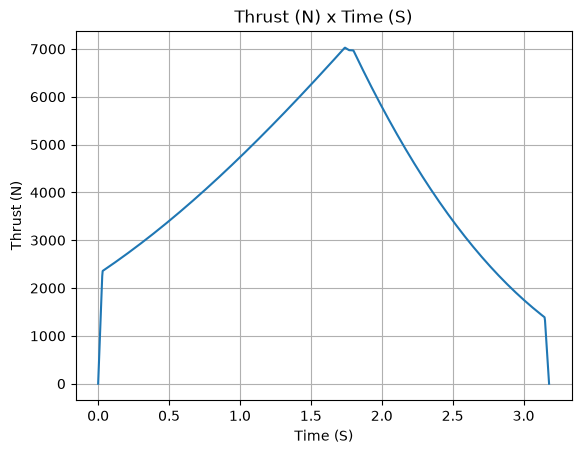

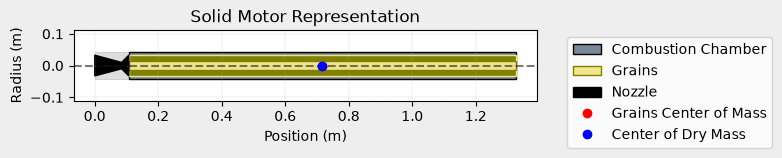

In [9]:
# Load both configurations from a version-2 JSON produced by cdx1tojson.py.
TWO_STAGE_JSON_PATH = PROJECT_DIR / "twostage.json"

full_stack_rocket = load_rocket(
    TWO_STAGE_JSON_PATH,
    rocket_key="full_stack",
    require_simulation_ready=True,
)
sustainer_rocket = load_rocket(
    TWO_STAGE_JSON_PATH,
    rocket_key="sustainer",
    require_simulation_ready=True,
)

full_stack_rocket.info()
full_stack_rocket.draw()
full_stack_rocket.motor.info()
full_stack_rocket.motor.draw()
sustainer_rocket.info()
sustainer_rocket.draw()
sustainer_rocket.motor.info()
sustainer_rocket.motor.draw()

Sustainer ignition tilt: 0.60 degrees from vertical



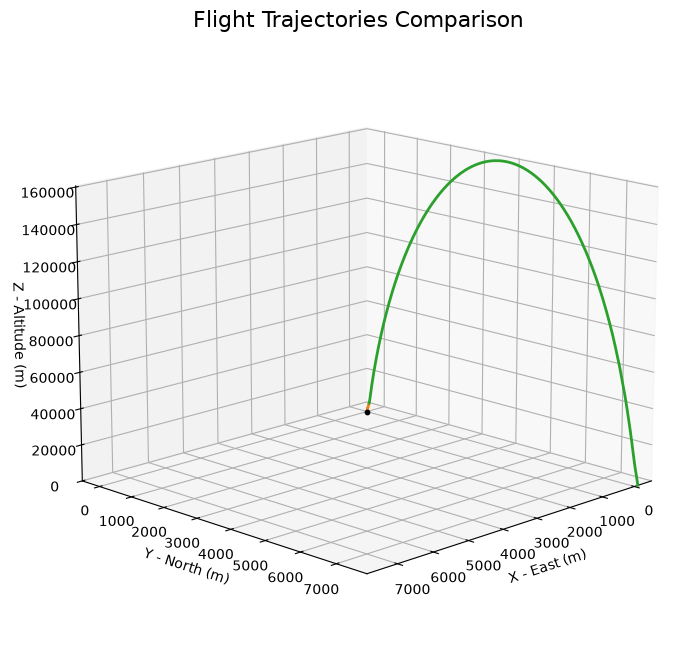

c:\Users\Ejfso\Documents\GitHub\projectblaze\sims\.venv\Lib\site-packages\rocketpy\plots\plot_helpers.py:65: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


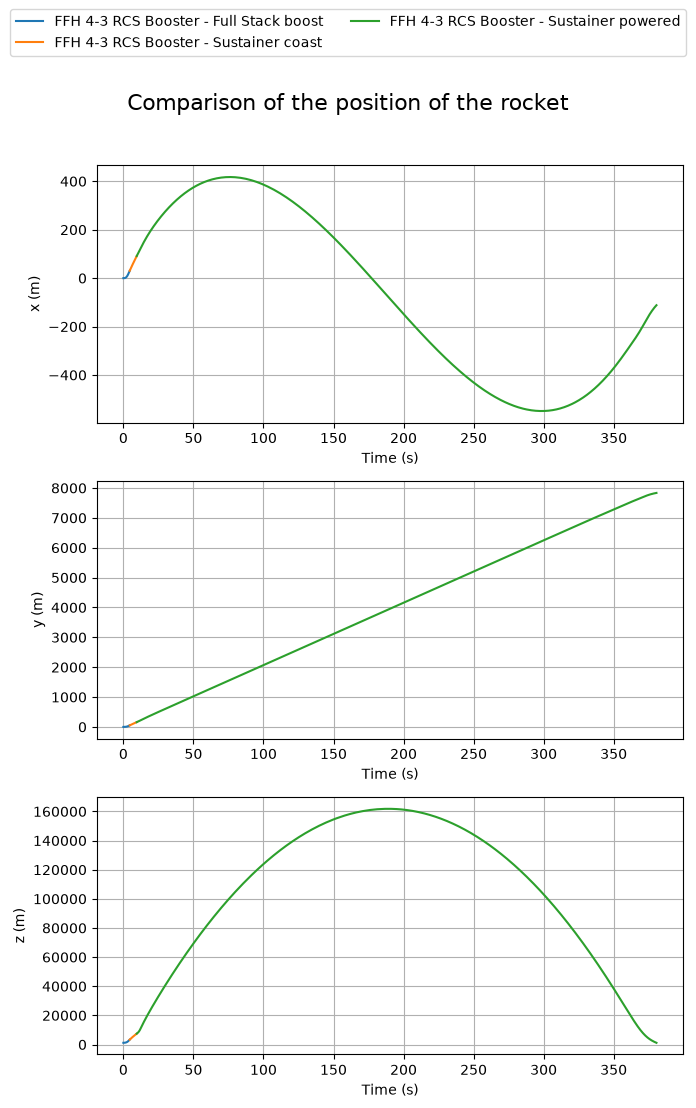

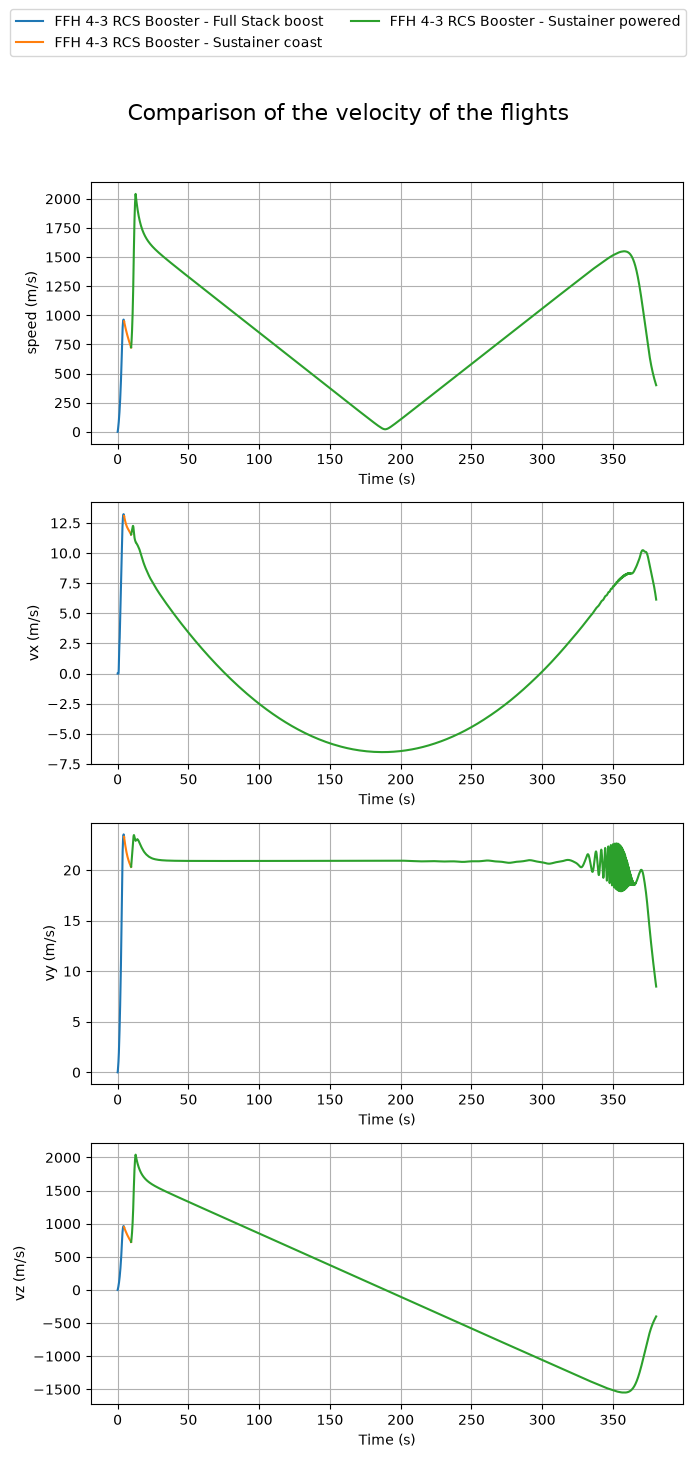

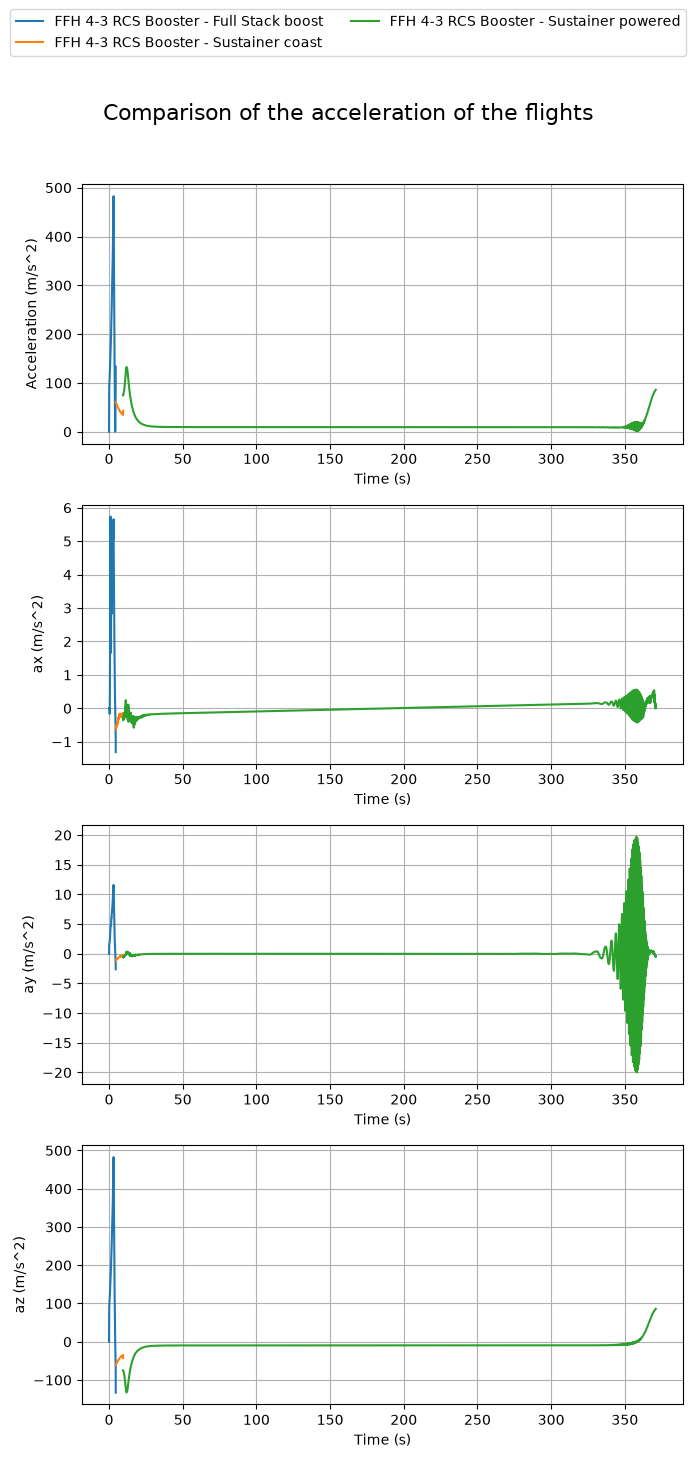

In [7]:
COAST_PERIOD = 5.0  # Seconds from booster burnout to sustainer ignition.

two_stage_solution = runfullstacksim(
    full_stack_rocket,
    sustainer_rocket,
    openmeteo_result.environment,
    time_limit=600.0,
    coast_period=COAST_PERIOD,
    rail_length=6.0,
    rod_angle=1.0,
    heading=0.0,
)


flight_comparison = CompareFlights(list(runfullstacksim.last_flights))

print()
flight_comparison.trajectories_3d()
flight_comparison.positions()
flight_comparison.velocities()
flight_comparison.accelerations()

